# LSTM + BỘ DỮ LIỆU KẾT HỢP

In [2]:
import pandas as pd
import numpy as np
import csv
import matplotlib.pyplot as plt
pd.options.mode.chained_assignment = None  # default='warn'
from sklearn.model_selection import train_test_split
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
import tensorflow as tf
from tensorflow.keras import layers, Model
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.layers import Input, Dense, Dropout, LayerNormalization, MultiHeadAttention, Concatenate, Reshape, Embedding, GlobalAveragePooling1D, Lambda

# Nhập và tiền xử lý dữ liệu

In [3]:
data_amp = pd.read_csv(r'../CSV_20k/genBank_20k/AMP_GenBank_20k.csv')
data_amp = data_amp.sample(10000)

In [4]:
data_namp = pd.read_csv(r'../CSV_20k/genBank_20k/nAMP_GenBank_20k.csv')
data_namp = data_namp.sample(10000)

In [5]:
combinated_data = pd.concat([data_amp, data_namp], ignore_index=True)

In [6]:
data_amp1 = pd.read_csv(r'../CSV_20k/notGenBank_20k/AMP_notGenBank_20k.csv')
data_amp1 = data_amp1.sample(10000)

In [7]:
data_namp1 = pd.read_csv(r'../CSV_20k/notGenBank_20k/nAMP_notGenBank_20k.csv')
data_namp1 = data_namp1.sample(10000)

In [8]:
combinated_data1 = pd.concat([data_amp1, data_namp1], ignore_index=True)

In [9]:
combinated_data = pd.concat([combinated_data, combinated_data1], ignore_index=True)

In [10]:
data, data_test = train_test_split(combinated_data, test_size=0.3, stratify=combinated_data['Label'], random_state=42, shuffle=True)

### Cột "ID" có thể chỉ là một định danh duy nhất cho từng dòng, không mang ý nghĩa đặc biệt trong mô hình.

In [11]:
data = data.drop(columns=['ID'])
data_test = data_test.drop(columns=['ID'])

In [12]:
data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 28000 entries, 14136 to 32782
Columns: 128 entries, Label to solvent_accessibility_exposed_100%
dtypes: float64(126), object(2)
memory usage: 27.6+ MB


In [13]:
data_test.info()

<class 'pandas.core.frame.DataFrame'>
Index: 12000 entries, 34342 to 19435
Columns: 128 entries, Label to solvent_accessibility_exposed_100%
dtypes: float64(126), object(2)
memory usage: 11.8+ MB


### Kiểm tra và xóa số lượng rows trùng lặp

In [14]:
data.duplicated().sum()

0

In [15]:
data_test.duplicated().sum()

0

In [16]:
data = data.drop_duplicates()
data_test = data_test.drop_duplicates()

In [17]:
data.duplicated().sum()

0

In [18]:
data_test.duplicated().sum()

0

### Kiểm tra xem có cột nào chứa giá trị NaN (khuyết thiếu) hay không.

In [19]:
null_columns_1 = data.columns[data.isnull().sum() > 0]
print(data[null_columns_1].isnull().sum())

null_columns_2 = data_test.columns[data_test.isnull().sum() > 0]
print(data[null_columns_2].isnull().sum())

Series([], dtype: float64)
Series([], dtype: float64)


### Phân loại các cột theo kiểu dữ liệu
#### - float_columns: Chứa các cột có kiểu dữ liệu float64 (biến số học).
#### - object_columns: Chứa các cột có kiểu dữ liệu object (biến dạng chuỗi).

In [20]:
float_columns = data.select_dtypes(include=['float64']).columns
object_columns = data.select_dtypes(include=['object']).columns

### Dữ liệu có 2 cột dạng chuỗi:
#### - Label: Có thể là nhãn phân loại (ví dụ: Antimicrobial vs Non-Antimicrobial hoặc 1 vs 0).
#### - Sequence: Chuỗi peptide cần dự đoán.

In [21]:
object_columns

Index(['Label', 'Sequence'], dtype='object')

### Chuyển đổi nhãn (Label) từ chuỗi sang số (0/1):
#### - Nếu Label == 'nAMP' → gán 0 (Không kháng khuẩn).
#### - Nếu không phải 'nAMP' → gán 1 (Kháng khuẩn).
### Chuyển đổi kiểu dữ liệu thành float để phù hợp với mô hình.

In [22]:
data.loc[:, 'Label'] = data['Label'].apply(lambda x: 0 if x == 'nAMP' else 1)
data['Label'] = data['Label'].astype(float)

data_test.loc[:, 'Label'] = data_test['Label'].apply(lambda x: 0 if x == 'nAMP' else 1)
data_test['Label'] = data_test['Label'].astype(float)

# data

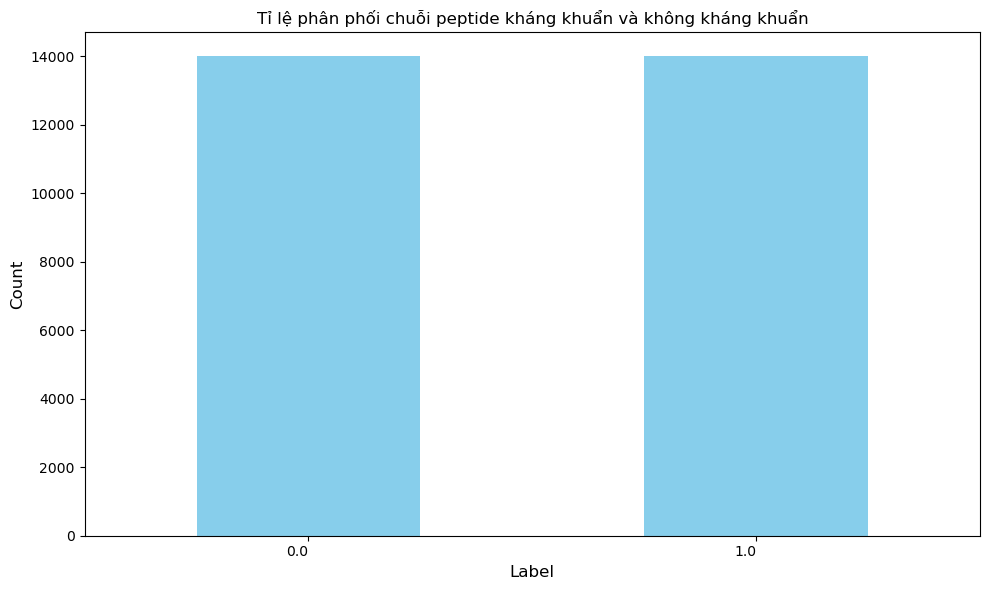

In [23]:
label_counts = data['Label'].value_counts()
plt.figure(figsize=(10, 6))
label_counts.plot(kind='bar', color = 'skyblue')
plt.title('Tỉ lệ phân phối chuỗi peptide kháng khuẩn và không kháng khuẩn')
plt.xlabel('Label', fontsize=12)
plt.ylabel('Count', fontsize=12)
plt.xticks(rotation=0, ha='right')
plt.tight_layout()
plt.show()

In [24]:
x_test = data_test.drop(columns=['Label'])
y_test = data_test['Label']

X_train = data.drop(columns=['Label'])
y_train = data['Label']

### Kiểm tra (mẫu, đặc trưng)

In [25]:
print(x_test.shape)
print(y_test.shape)

print(X_train.shape)
print(y_train.shape)

(12000, 127)
(12000,)
(28000, 127)
(28000,)


In [26]:
X_val, X_test, Y_val, Y_test = train_test_split(x_test, y_test, test_size=0.5, stratify=y_test, random_state=42, shuffle=True)

### chuỗi sequence dạng chữ, chuyển về chuỗi số

In [27]:
# sequence_lengths = [len(seq) for seq in  data['Sequence']]  

# # Tính giá trị percentile 95%
# max_length = int(np.percentile(sequence_lengths, 95))  
# print(f"Max length hợp lý dựa trên 95% dữ liệu: {max_length}")

### Đệm hoặc cắt ở phía sau
###  Lý do chọn 'post':
#### - Giữ thông tin quan trọng ở đầu chuỗi, vì đầu peptide có thể chứa thông tin quan trọng về tính kháng khuẩn.

In [28]:
# pip install tensorflow

In [29]:
max_length = 50

padding_type = 'post' # Đệm thêm số 0
trunc_type = 'post'  # Cắt nếu chuỗi dài

In [30]:
tokenizer = Tokenizer(char_level=True)
tokenizer.fit_on_texts(data['Sequence'])
vocab_size = len(tokenizer.word_index) + 1
print("Vocab Size: ",vocab_size)

Vocab Size:  22


In [31]:
tokenizer.word_index

{'r': 1,
 'a': 2,
 'l': 3,
 'g': 4,
 'v': 5,
 'k': 6,
 's': 7,
 't': 8,
 'i': 9,
 'p': 10,
 'f': 11,
 'q': 12,
 'e': 13,
 'n': 14,
 'd': 15,
 'y': 16,
 'h': 17,
 'm': 18,
 'w': 19,
 'c': 20,
 'x': 21}

In [32]:
train_sequences  = tokenizer.texts_to_sequences(X_train['Sequence'])
train_sequence_array = pad_sequences(train_sequences , maxlen= max_length, padding= padding_type, truncating=trunc_type)

val_sequences = tokenizer.texts_to_sequences(X_val['Sequence'])
val_sequence_array = pad_sequences(val_sequences , maxlen= max_length, padding= padding_type, truncating=trunc_type)

test_sequences = tokenizer.texts_to_sequences(X_test['Sequence'])
test_sequence_array = pad_sequences(test_sequences , maxlen= max_length, padding= padding_type, truncating=trunc_type)

In [33]:
X_train= X_train.drop(columns=['Sequence'])
X_train['train_sequences'] = train_sequence_array.tolist()

X_val= X_val.drop(columns=['Sequence'])
X_val['val_sequences'] = val_sequence_array.tolist()

X_test= X_test.drop(columns=['Sequence'])
X_test['test_sequences'] = test_sequence_array.tolist()

In [34]:
X_train.describe()

,hydrophobicity_polar_first,hydrophobicity_polar_20%,hydrophobicity_polar_40%,hydrophobicity_polar_60%,hydrophobicity_polar_80%,hydrophobicity_polar_100%,hydrophobicity_neutral_first,hydrophobicity_neutral_20%,hydrophobicity_neutral_40%,hydrophobicity_neutral_60%,...,solvent_accessibility_intermediate_40%,solvent_accessibility_intermediate_60%,solvent_accessibility_intermediate_80%,solvent_accessibility_intermediate_100%,solvent_accessibility_exposed_first,solvent_accessibility_exposed_20%,solvent_accessibility_exposed_40%,solvent_accessibility_exposed_60%,solvent_accessibility_exposed_80%,solvent_accessibility_exposed_100%
count,28000.000000,28000.000000,28000.000000,28000.000000,28000.000000,28000.000000,28000.000000,28000.000000,28000.000000,28000.000000,...,28000.000000,28000.000000,28000.000000,28000.000000,28000.000000,28000.000000,28000.000000,28000.000000,28000.000000,28000.000000
mean,0.214145,0.288914,0.504098,0.642855,0.855005,0.890869,0.211659,0.291031,0.459717,0.626404,...,0.432253,0.571803,0.689942,0.710231,0.214145,0.288914,0.504098,0.642855,0.855005,0.890869
std,0.177205,0.185471,0.201663,0.200818,0.171022,0.166802,0.174571,0.165884,0.177233,0.181630,...,0.237286,0.259785,0.285544,0.293674,0.177205,0.185471,0.201663,0.200818,0.171022,0.166802
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.100000,0.138587,0.357143,0.500000,0.800000,0.823004,0.100000,0.200000,0.333333,0.500000,...,0.285714,0.400000,0.583333,0.600000,0.100000,0.138587,0.357143,0.500000,0.800000,0.823004
50%,0.153846,0.250000,0.500000,0.695652,0.900000,1.000000,0.153846,0.266667,0.450000,0.631579,...,0.409091,0.600000,0.791667,0.800000,0.153846,0.250000,0.500000,0.695652,0.900000,1.000000
75%,0.300000,0.400000,0.647059,0.800000,1.000000,1.000000,0.300000,0.400000,0.600000,0.750000,...,0.600000,0.772727,0.900000,0.923077,0.300000,0.400000,0.647059,0.800000,1.000000,1.000000
max,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,...,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


In [35]:
columns_with_max_equal_1 = X_train.columns[X_train.max() == 1]
columns_with_min_equal_0 = X_train.columns[X_train.min() == 0]

# In kết quả
print("Các cột có max == 1:", len(list(columns_with_max_equal_1)))
print("Các cột có min == 0:", len(list(columns_with_min_equal_0)))

Các cột có max == 1: 124
Các cột có min == 0: 123


## Kiểm tra X_train
#### Tổng có 127 cột. Tách thành 126 + 1 cột mảng

In [36]:
print(X_train.dtypes.value_counts())

float64    126
object       1
Name: count, dtype: int64


In [37]:
X_train_num = X_train.iloc[:, :126]  # Chọn 126 cột đầu tiên
X_train_text = X_train.iloc[:, -1]   # Chọn cột cuối cùng

In [38]:
object_cols = X_train.select_dtypes(include=['object']).columns
print("Cột object:", object_cols)

Cột object: Index(['train_sequences'], dtype='object')


In [39]:
print(X_train_text.head(10))  # Xem 10 dòng đầu

14136    [4, 8, 13, 1, 12, 6, 5, 11, 1, 8, 0, 0, 0, 0, ...
30437    [9, 16, 14, 10, 8, 6, 3, 16, 12, 6, 0, 0, 0, 0...
810      [3, 2, 8, 3, 2, 12, 4, 2, 19, 3, 3, 5, 3, 4, 1...
21267    [19, 1, 8, 9, 4, 4, 6, 3, 6, 5, 0, 0, 0, 0, 0,...
18040    [12, 8, 3, 5, 4, 1, 7, 8, 7, 1, 0, 0, 0, 0, 0,...
24981    [18, 4, 2, 9, 5, 2, 9, 5, 4, 1, 10, 14, 5, 4, ...
30008    [9, 13, 3, 1, 1, 8, 2, 15, 1, 6, 0, 0, 0, 0, 0...
21860    [9, 1, 15, 5, 1, 2, 9, 2, 14, 6, 9, 12, 1, 9, ...
12046    [3, 20, 4, 6, 14, 7, 3, 8, 6, 9, 15, 9, 7, 6, ...
24035    [2, 3, 9, 3, 19, 9, 4, 4, 18, 1, 2, 5, 13, 4, ...
Name: train_sequences, dtype: object


## Kiểm tra X_val
#### Tổng có 127 cột. Tách thành 126 + 1 cột mảng

In [40]:
print(X_val.dtypes.value_counts())

float64    126
object       1
Name: count, dtype: int64


In [41]:
X_val_num = X_val.iloc[:, :126]  # Chọn 126 cột đầu tiên
X_val_text = X_val.iloc[:, -1]   # Chọn cột cuối cùng

In [42]:
print(X_val_text.head(10))  # Xem 10 dòng đầu

18096    [10, 7, 16, 13, 12, 5, 20, 13, 4, 6, 0, 0, 0, ...
38495    [16, 3, 2, 6, 1, 3, 7, 15, 15, 1, 0, 0, 0, 0, ...
31614    [7, 5, 7, 18, 6, 15, 5, 16, 1, 14, 0, 0, 0, 0,...
36960    [13, 14, 6, 3, 13, 1, 2, 3, 3, 12, 6, 1, 13, 1...
25563    [2, 7, 2, 2, 6, 18, 3, 3, 6, 6, 0, 0, 0, 0, 0,...
4958     [6, 1, 11, 3, 4, 5, 5, 1, 19, 12, 4, 18, 11, 0...
33284    [13, 1, 16, 1, 2, 3, 13, 2, 1, 1, 0, 0, 0, 0, ...
5432     [3, 3, 2, 10, 3, 5, 5, 1, 1, 1, 0, 0, 0, 0, 0,...
29927    [6, 3, 6, 13, 10, 1, 2, 3, 3, 3, 6, 20, 11, 11...
22615    [1, 3, 2, 5, 1, 4, 2, 8, 8, 2, 1, 4, 4, 0, 0, ...
Name: val_sequences, dtype: object


## Kiểm tra dữ liệu huấn luyện
In thử một vài giá trị trong X_train và X_val để kiểm tra xem có giá trị âm hoặc không hợp lệ không

In [43]:
print(f"X_train_text - NaN: {pd.isna(X_train_text).sum()} / Total: {X_train_text.size}")
print(f"X_val_text - NaN: {pd.isna(X_val_text).sum()} / Total: {X_val_text.size}")

X_train_text - NaN: 0 / Total: 28000
X_val_text - NaN: 0 / Total: 6000


In [44]:
# X_train_num = np.array(X_train_num, dtype=np.float32)
# X_val_num = np.array(X_val_num, dtype=np.float32)
X_train_num = X_train_num.to_numpy(dtype=np.float32)
X_val_num = X_val_num.to_numpy(dtype=np.float32)

In [45]:
# Định nghĩa độ dài cố định cho X_train_text và X_val_text
max_len = max_length  

# Chuyển đổi tất cả thành danh sách cùng kích thước
X_train_text = np.array([seq[:max_len] + [0] * (max_len - len(seq)) if len(seq) < max_len else seq[:max_len] for seq in X_train_text], dtype=np.int32)

X_val_text = np.array([seq[:max_len] + [0] * (max_len - len(seq)) if len(seq) < max_len else seq[:max_len] for seq in X_val_text], dtype=np.int32)

print("X_train_text shape:", X_train_text.shape)
print("X_val_text shape:", X_val_text.shape)

X_train_text shape: (28000, 50)
X_val_text shape: (6000, 50)


### MODEL LSTM

In [46]:
import numpy as np

# Số timestep (phải khớp với chiều thứ 2 của X_train_text)
timesteps = 50  # ví dụ: 50

# Reshape từ (samples, timesteps) => (samples, timesteps, 1)
X_train_seq = X_train_text.reshape(-1, timesteps, 1)
X_val_seq = X_val_text.reshape(-1, timesteps, 1)

# Đặc trưng số học thành mảng 3D
X_train_num_np = X_train_num.reshape(-1, 126, 1).astype(np.float32)
X_val_num_np = X_val_num.reshape(-1, 126, 1).astype(np.float32)

# Nhãn đầu ra
y_train_np = y_train.values.reshape(-1, 1).astype(np.float32)
y_val_np = Y_val.values.reshape(-1, 1).astype(np.float32)
y_test_np = Y_test.values.reshape(-1, 1).astype(np.float32)

In [47]:
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, LSTM, Dense, Concatenate, Dropout, BatchNormalization
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping, ReduceLROnPlateau

# === Tham số mô hình ===
num_timesteps_num = X_train_num_np.shape[1]   # 126
num_features_num = X_train_num_np.shape[2]    # 1
timesteps = X_train_seq.shape[1]              # ví dụ: 50
vocab_size = X_train_seq.max() + 1            # nếu là categorical input thì dùng Embedding

embedding_dim = 128
lstm_units = 128
dropout_rate = 0.2
dense_1_units = 128
dense_2_units = 64
output_units = 1  

# === Nhánh 1: Dữ liệu chuỗi ===
sequence_input = Input(shape=(timesteps, 1), name="sequence_input")
x1 = LSTM(lstm_units, return_sequences=False)(sequence_input)
x1 = BatchNormalization()(x1)
x1 = Dropout(dropout_rate)(x1)

# === Nhánh 2: Dữ liệu số ===
numerical_input = Input(shape=(num_timesteps_num, num_features_num), name="numerical_input")
x2 = LSTM(lstm_units, return_sequences=False)(numerical_input)
x2 = BatchNormalization()(x2)
x2 = Dropout(dropout_rate)(x2)

# === Kết hợp hai nhánh ===
combined = Concatenate()([x1, x2])

# === Dense layers ===
x = Dense(dense_1_units, activation='relu')(combined)
x = BatchNormalization()(x)
x = Dropout(dropout_rate)(x)
x = Dense(dense_2_units, activation='relu')(x)
x = BatchNormalization()(x)

# === Output ===
output = Dense(output_units, activation='linear', name="output")(x)  # Nếu regression

In [48]:
# === Tạo model ===
model = Model(inputs=[sequence_input, numerical_input], outputs=output)

# === Compile model ===
optimizer = Adam(learning_rate=0.00001)  # Tăng learning rate nhẹ lên từ 1e-5 → 1e-4
model.compile(optimizer=optimizer, loss="mse", metrics=["accuracy"])
model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                  ┃ Output Shape              ┃         Param # ┃ Connected to               ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│ sequence_input (InputLayer)   │ (None, 50, 1)             │               0 │ -                          │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ numerical_input (InputLayer)  │ (None, 126, 1)            │               0 │ -                          │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ lstm (LSTM)                   │ (None, 128)               │          66,560 │ sequence_input[0][0]       │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ lstm_1 (LSTM)                 │ (None, 128)               │          66,560 │ numerical_input[0][0]      │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ batch_normalization           │ (None, 128)               │             512 │ lstm[0][0]                 │
│ (BatchNormalization)          │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ batch_normalization_1         │ (None, 128)               │             512 │ lstm_1[0][0]               │
│ (BatchNormalization)          │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ dropout (Dropout)             │ (None, 128)               │               0 │ batch_normalization[0][0]  │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ dropout_1 (Dropout)           │ (None, 128)               │               0 │ batch_normalization_1[0][… │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ concatenate (Concatenate)     │ (None, 256)               │               0 │ dropout[0][0],             │
│                               │                           │                 │ dropout_1[0][0]            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ dense (Dense)                 │ (None, 128)               │          32,896 │ concatenate[0][0]          │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ batch_normalization_2         │ (None, 128)               │             512 │ dense[0][0]                │
│ (BatchNormalization)          │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ dropout_2 (Dropout)           │ (None, 128)               │               0 │ batch_normalization_2[0][… │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ dense_1 (Dense)               │ (None, 64)                │           8,256 │ dropout_2[0][0]            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ batch_normalization_3         │ (None, 64)                │             256 │ dense_1[0][0]              │
│ (BatchNormalization)          │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ output (Dense)                │ (None, 1)                 │              6

 Total params: 176,129 (688.00 KB)

 Trainable params: 175,233 (684.50 KB)

 Non-trainable params: 896 (3.50 KB)

In [49]:
# === Callbacks ===
weight_path = "{}_weights.best.weights.h5".format('LSTM_combinate')

checkpoint = ModelCheckpoint(
    filepath=weight_path,
    monitor='val_loss',
    verbose=1,
    save_best_only=True,
    save_weights_only=True,
    mode='min'
)

early = EarlyStopping(
    monitor='val_loss',
    mode='min',
    patience=149,
    verbose=1,
    restore_best_weights=True
)

reduce = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=5,
    verbose=1
)

callbacks_list = [checkpoint, early, reduce]

In [50]:
# === Huấn luyện ===
history = model.fit(
    [X_train_seq, X_train_num_np],
    y_train_np,
    validation_data=([X_val_seq, X_val_num_np], y_val_np),
    epochs=150,
    batch_size=32,
    callbacks=callbacks_list
)

Epoch 1/150
875/875 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step - accuracy: 0.5140 - loss: 1.7276
Epoch 1: val_loss improved from inf to 0.37759, saving model to LSTM_combinate_weights.best.weights.h5
875/875 ━━━━━━━━━━━━━━━━━━━━ 52s 54ms/step - accuracy: 0.5140 - loss: 1.7272 - val_accuracy: 0.5915 - val_loss: 0.3776 - learning_rate: 1.0000e-05
Epoch 2/150
874/875 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step - accuracy: 0.5491 - loss: 0.9931
Epoch 2: val_loss did not improve from 0.37759
875/875 ━━━━━━━━━━━━━━━━━━━━ 46s 53ms/step - accuracy: 0.5491 - loss: 0.9929 - val_accuracy: 0.6160 - val_loss: 0.3828 - learning_rate: 1.0000e-05
Epoch 3/150
875/875 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step - accuracy: 0.5668 - loss: 0.7353
Epoch 3: val_loss improved from 0.37759 to 0.31710, saving model to LSTM_combinate_weights.best.weights.h5
875/875 ━━━━━━━━━━━━━━━━━━━━ 47s 53ms/step - accuracy: 0.5668 - loss: 0.7352 - val_accuracy: 0.6392 - val_loss: 0.3171 - learning_rate: 1.0000e-05
Epoch 4/150
875/875 ━━━━━━━━━━━━━━━━━━

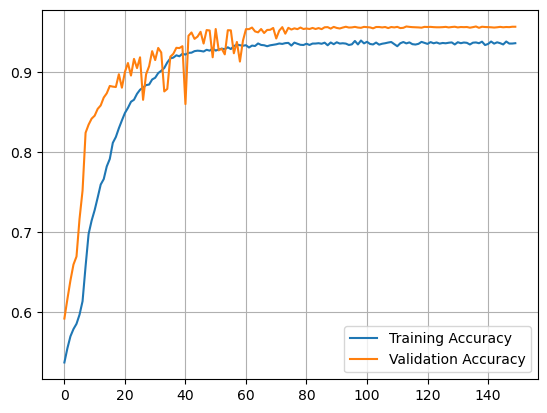

In [51]:
def plot_history_accuracy(history):
    plt.plot(history.history["accuracy"], label="Training Accuracy")
    plt.plot(history.history["val_accuracy"], label="Validation Accuracy")
    plt.legend()
    plt.grid()
    plt.show()

plot_history_accuracy(history=history)

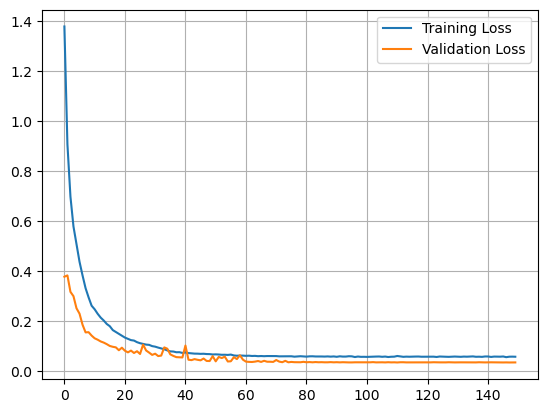

In [52]:
def plot_history_loss(history):
    plt.plot(history.history["loss"], label="Training Loss")
    plt.plot(history.history["val_loss"], label="Validation Loss")
    plt.legend()
    plt.grid()
    plt.show()

plot_history_loss(history=history)

In [53]:
X_test_num = X_test.iloc[:, :126]  # Chọn 126 cột đầu tiên
X_test_text = X_test.iloc[:, -1]   # Chọn cột cuối cùng

# X_test_num = np.array(X_test_num, dtype=np.float32)
X_test_num = X_test_num.to_numpy(dtype=np.float32)
X_test_num_np = X_test_num.reshape(-1, 126, 1).astype(np.float32)

In [54]:
# Định nghĩa độ dài cố định cho X_train_text và X_val_text
max_len = max_length

# Chuyển đổi tất cả thành danh sách cùng kích thước
# X_test_text = np.array([seq[:max_len] + [0] * (max_len - len(seq)) if len(seq) < max_len else seq[:max_len] for seq in X_test_text], dtype=np.int32)
X_test_text = test_sequence_array
X_test_seq = X_test_text.reshape(-1, timesteps, 1)

print("X_train_text shape:", X_test_seq.shape)

X_train_text shape: (6000, 50, 1)


In [55]:
predictions = model.predict([X_test_seq, X_test_num_np], verbose=True)
predictions = (predictions >= 0.5).astype(int)

188/188 ━━━━━━━━━━━━━━━━━━━━ 9s 46ms/step


In [56]:
from sklearn.metrics import classification_report,confusion_matrix

print(classification_report(Y_test, predictions, target_names=['nAMP (Class 0)', 'AMP (Class 1)']))

                precision    recall  f1-score   support

nAMP (Class 0)       0.95      0.96      0.95      3000
 AMP (Class 1)       0.96      0.95      0.95      3000

      accuracy                           0.95      6000
     macro avg       0.95      0.95      0.95      6000
  weighted avg       0.95      0.95      0.95      6000



In [57]:
cm = confusion_matrix(Y_test, predictions)
cm = pd.DataFrame(cm, index=['nAMP', 'AMP'], columns=['nAMP', 'AMP'])

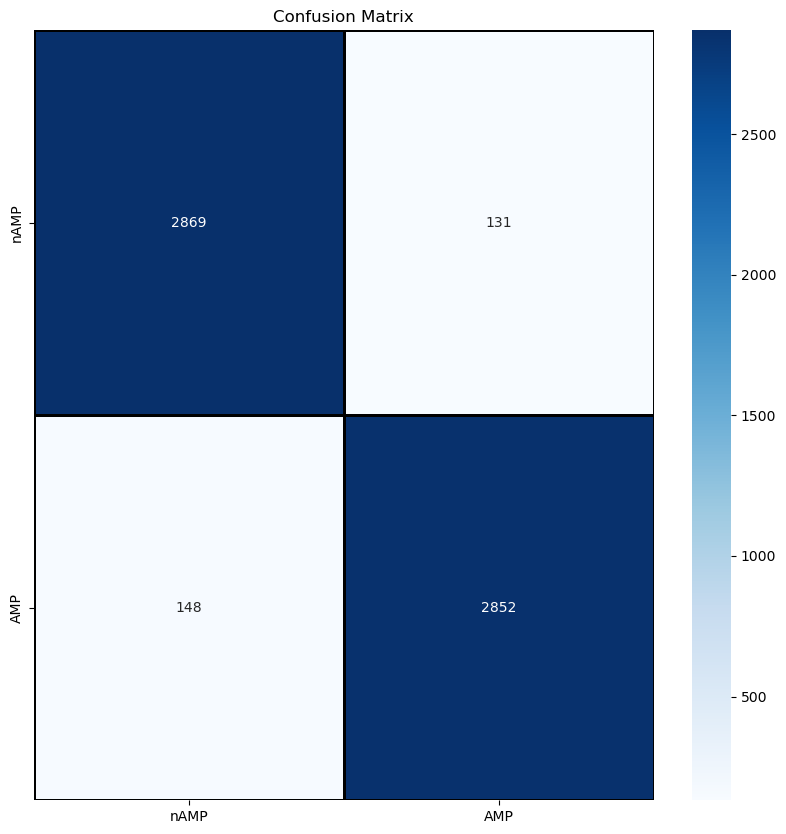

In [58]:
import seaborn as sns

plt.figure(figsize=(10, 10))
sns.heatmap(cm, cmap="Blues", linecolor='black', linewidth=1, annot=True, fmt='d', xticklabels=cm.columns, yticklabels=cm.index)
plt.title('Confusion Matrix')
plt.show()

# EXPLAINABLE AI

In [59]:
model.load_weights('LSTM_combinate_weights.best.weights.h5')

In [60]:
def compute_saliency_sequence_branch(model, input_seq_tensor, input_num_tensor):
    input_seq_tensor = tf.convert_to_tensor(input_seq_tensor)
    input_seq_tensor = tf.cast(input_seq_tensor, tf.float32)
    input_num_tensor = tf.convert_to_tensor(input_num_tensor)
    input_num_tensor = tf.cast(input_num_tensor, tf.float32)

    with tf.GradientTape() as tape:
        tape.watch(input_seq_tensor)

        prediction = model([input_seq_tensor, input_num_tensor], training=False)

    grads = tape.gradient(prediction, input_seq_tensor)

    if grads is None:
        raise ValueError("Gradient could not be computed. Ensure input is used in computation graph.")
    
    saliency = tf.abs(grads).numpy()
    return saliency

In [61]:
# Giả sử bạn muốn giải thích cho sample đầu tiên
x_seq = X_val_seq[1:2]  # (1, 50, 1)
x_num = X_val_num_np[1:2]   # (1, 126, 1)

# Tính saliency
saliency_map = compute_saliency_sequence_branch(model, x_seq, x_num)  # (1, 50, 1)

# Tính độ quan trọng tại từng vị trí (mean theo chiều cuối)
mean_saliency = np.mean(saliency_map[0], axis=-1)  # (50,)

In [62]:
# 1. Tạo ánh xạ ngược từ số về ký tự
index_to_char = {v: k.upper() for k, v in tokenizer.word_index.items()}
index_to_char[0] = 'PAD'

# 2. Flatten và chuyển token
token_indices = x_seq[0].flatten().astype(int)
feature_names = [index_to_char.get(idx, '?') for idx in token_indices]

# 3. Lọc bỏ PAD khỏi cả feature_names và mean_saliency
filtered_feature_names = []
filtered_saliency = []

for name, score in zip(feature_names, mean_saliency):
    if name != 'PAD':
        filtered_feature_names.append(name)
        filtered_saliency.append(score)

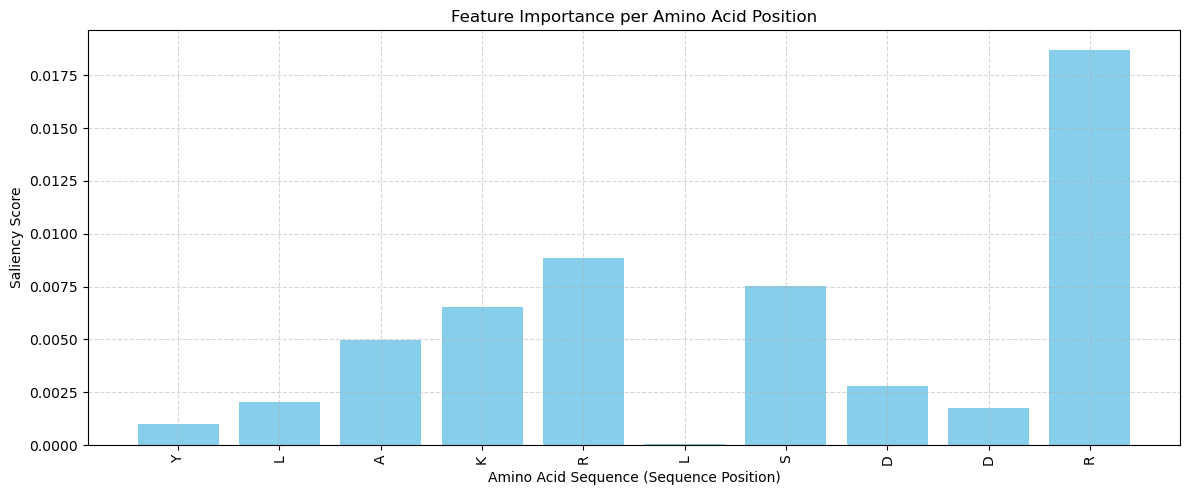

In [63]:
plt.figure(figsize=(12, 6))
bars = plt.bar(range(len(filtered_saliency)), filtered_saliency, color='skyblue')
plt.xticks(range(len(filtered_saliency)), filtered_feature_names, rotation=90)
plt.xlabel("Amino Acid Sequence (Sequence Position)")
plt.ylabel("Saliency Score")
plt.title("Feature Importance per Amino Acid Position")
plt.grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.subplots_adjust(bottom=0.25)
plt.show()